#### Build Chatbot With Tools

##### Import all the libraries

In [ ]:
import os
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [13]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [15]:
load_dotenv()

True

In [16]:
llm=ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AF228E2990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AF228E3390>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

#### Bind with tools

In [17]:
tool = TavilySearch(max_results=2)


In [18]:
def addition(a:int,b:int)->int:
    """_addition_

    Args:
        a (int): _first integer_
        b (int): _secondinteger_

    Returns:
        int: _result_
    """
    return a+b

In [19]:
tools = [tool , addition]

In [20]:
llm_with_tools = llm.bind_tools(tools)

#### Build Graph

In [35]:
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

In [36]:
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm" , tool_calling_llm)
graph_builder.add_node("tools" , ToolNode(tools))

#### The ReACT Agent Part

In [ ]:
graph_builder.add_edge(START , "tool_calling_llm")
graph_builder.add_conditional_edges("tool_calling_llm", tools_condition)
## instead of going to the END tool node go back to the tool calling llm
graph_builder.add_edge("tools" , "tool_calling_llm")


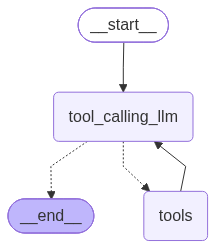

In [38]:
graph_builder.compile()

In [40]:
graph = graph_builder.compile()

In [41]:
response = graph.invoke({"messages":"Hi! Give me latest AI News and the add 2 and 7"})

In [42]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi! Give me latest AI News and the add 2 and 7
================================== Ai Message ==================================
Tool Calls:
  tavily_search (m1qnx5chj)
 Call ID: m1qnx5chj
  Args:
    query: latest AI news
    time_range: day
    topic: news
  addition (gmbz8wzhs)
 Call ID: gmbz8wzhs
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/developers-tools/ai-agents-intensive-recap-2026", "title": "Inside our 353,000-person vibe coding course", "content": "Image 7 AI ### The latest AI news we announced in June 2026 By News from Google Team\n\nImage 8 AI ### Ask an AI expert: What exactly is the full stack? By Molly McHugh-Johnson\n\n## Get the latest news from Googl